# BERT Classification Practice using AG News Dataset

## Practice Overview
In this practice, we will build a model that classifies news articles into 4 categories using the BERT model with the AG News English news dataset.

### AG News Dataset
- **Categories**: 4 (World, Sports, Business, Sci/Tech)
- **Training Data**: 120,000 samples (Using 3% for quick demo: ~3,600)
- **Test Data**: 7,600 samples (Using 3%: ~228)
- **Content**: News titles and descriptions

## 1. Environment Setup

In [1]:
# Install required libraries
!pip install transformers datasets torch scikit-learn pandas numpy matplotlib seaborn --quiet

In [2]:
# Import libraries
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from transformers import BertTokenizer, BertForSequenceClassification
from transformers import get_linear_schedule_with_warmup
from torch.optim import AdamW  # ⚠️ Modified: import from torch.optim instead of transformers
from torch.utils.data import TensorDataset, DataLoader, RandomSampler, SequentialSampler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import time
import datetime
import random

# Check versions
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

# Set seed for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

PyTorch version: 2.8.0+cu126
CUDA available: True


## 2. GPU Setup

In [3]:
# GPU setup
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f'Found GPU at: {torch.cuda.get_device_name(0)}')
    print(f'There are {torch.cuda.device_count()} GPU(s) available.')
else:
    print('No GPU available, using CPU instead.')
    device = torch.device("cpu")

Found GPU at: Tesla T4
There are 1 GPU(s) available.


## 3. Loading Data

In [4]:
# Load AG News dataset (using Hugging Face datasets library)
print("Loading AG News dataset...")
dataset = load_dataset('ag_news')

print(f"\nNumber of training data: {len(dataset['train'])}")
print(f"Number of test data: {len(dataset['test'])}")

# Check data samples
print("\n=== Data Samples ===\n")
for i in range(3):
    print(f"Example {i+1}:")
    print(f"Label: {dataset['train'][i]['label']}")
    print(f"Text: {dataset['train'][i]['text'][:100]}...\n")

Loading AG News dataset...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]


Number of training data: 120000
Number of test data: 7600

=== Data Samples ===

Example 1:
Label: 2
Text: Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\b...

Example 2:
Label: 2
Text: Carlyle Looks Toward Commercial Aerospace (Reuters) Reuters - Private investment firm Carlyle Group,...

Example 3:
Label: 2
Text: Oil and Economy Cloud Stocks' Outlook (Reuters) Reuters - Soaring crude prices plus worries\about th...



In [5]:
# Convert to DataFrame (correct method)
# ⚠️ Important: Use the original structure of AG News dataset as is
train_df = dataset['train'].to_pandas()  # or pd.DataFrame(dataset['train'])
test_df = dataset['test'].to_pandas()

# Check data structure
print("\n=== Data Structure Check ===\n")
print(f"Column names: {train_df.columns.tolist()}")
print(f"Data types:\n{train_df.dtypes}")

# AG News dataset already has 'label' and 'text' columns
# No need to force column name changes!

print("\n=== Training Data Preview ===\n")
print(train_df.head())

# Check data types
print("\n=== Sample Data Check ===\n")
print(f"Label Example: {train_df['label'].iloc[0]} (Type: {type(train_df['label'].iloc[0])})")
print(f"Text Example: {train_df['text'].iloc[0][:100]}... (Type: {type(train_df['text'].iloc[0])})")

# Check label distribution
print("\n=== Label Distribution ===\n")
label_names = {0: 'World', 1: 'Sports', 2: 'Business', 3: 'Sci/Tech'}
print(train_df['label'].value_counts().sort_index())

# Print category names
print("\n=== Category Mapping ===\n")
for idx, name in label_names.items():
    count = (train_df['label'] == idx).sum()
    print(f"{idx}: {name} - {count}samples")


=== Data Structure Check ===

Column names: ['text', 'label']
Data types:
text     object
label     int64
dtype: object

=== Training Data Preview ===

                                                text  label
0  Wall St. Bears Claw Back Into the Black (Reute...      2
1  Carlyle Looks Toward Commercial Aerospace (Reu...      2
2  Oil and Economy Cloud Stocks' Outlook (Reuters...      2
3  Iraq Halts Oil Exports from Main Southern Pipe...      2
4  Oil prices soar to all-time record, posing new...      2

=== Sample Data Check ===

Label Example: 2 (Type: <class 'numpy.int64'>)
Text Example: Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\b... (Type: <class 'str'>)

=== Label Distribution ===

label
0    30000
1    30000
2    30000
3    30000
Name: count, dtype: int64

=== Category Mapping ===

0: World - 30000samples
1: Sports - 30000samples
2: Business - 30000samples
3: Sci/Tech - 30000samples


## 4. Data Sampling (Optional)

You can use only a portion of the data for quick practice.

In [6]:
# Set data sampling ratio (1.0 = use all, 0.1 = use 10%)
SAMPLE_RATIO = 0.03  # Use only 3% for quick classroom demo (change to 1.0 if needed)

if SAMPLE_RATIO < 1.0:
    train_df = train_df.sample(frac=SAMPLE_RATIO, random_state=42).reset_index(drop=True)
    test_df = test_df.sample(frac=SAMPLE_RATIO, random_state=42).reset_index(drop=True)
    print(f"\nTraining data after sampling: {len(train_df)}samples")
    print(f"Test data after sampling: {len(test_df)}samples")
else:
    print("\nUsing all data.")


Training data after sampling: 3600samples
Test data after sampling: 228samples


## 5. Text Length Analysis

=== Text Length Statistics ===

Average word count: 37.82
Maximum word count: 150
Minimum word count: 9
Median: 37.00
Standard deviation: 10.25

=== Percentiles ===

25th percentile: 32 words
50th percentile: 37 words
75th percentile: 43 words
90th percentile: 48 words
95th percentile: 53 words
99th percentile: 70 words


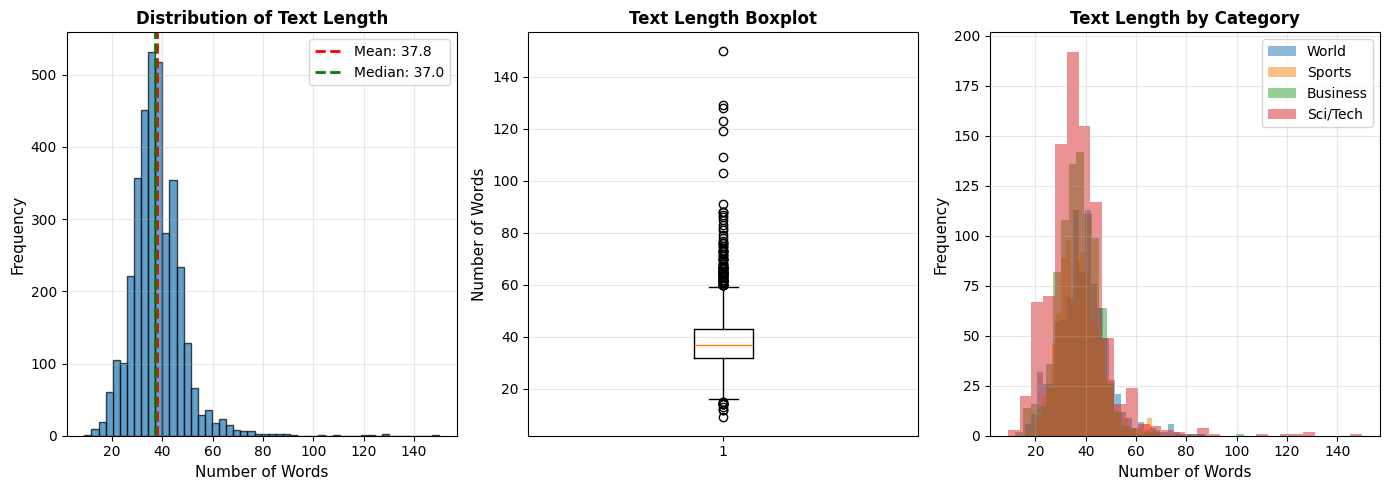


=== Average Word Count by Category ===

World       : 39.02 words
Sports      : 37.83 words
Business    : 37.34 words
Sci/Tech    : 37.10 words


In [7]:
# Text length analysis
# ✅ Safe method: ensure string by converting with str()
train_df['text_length'] = train_df['text'].apply(lambda x: len(str(x).split()))

print("=== Text Length Statistics ===\n")
print(f"Average word count: {train_df['text_length'].mean():.2f}")
print(f"Maximum word count: {train_df['text_length'].max()}")
print(f"Minimum word count: {train_df['text_length'].min()}")
print(f"Median: {train_df['text_length'].median():.2f}")
print(f"Standard deviation: {train_df['text_length'].std():.2f}")

# Check percentiles
print("\n=== Percentiles ===\n")
for percentile in [25, 50, 75, 90, 95, 99]:
    value = np.percentile(train_df['text_length'], percentile)
    print(f"{percentile}th percentile: {value:.0f} words")

# Visualize text length distribution
plt.figure(figsize=(14, 5))

plt.subplot(1, 3, 1)
plt.hist(train_df['text_length'], bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Number of Words', fontsize=11)
plt.ylabel('Frequency', fontsize=11)
plt.title('Distribution of Text Length', fontsize=12, fontweight='bold')
plt.axvline(train_df['text_length'].mean(), color='red', linestyle='--',
            linewidth=2, label=f'Mean: {train_df["text_length"].mean():.1f}')
plt.axvline(train_df['text_length'].median(), color='green', linestyle='--',
            linewidth=2, label=f'Median: {train_df["text_length"].median():.1f}')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 2)
plt.boxplot(train_df['text_length'], vert=True)
plt.ylabel('Number of Words', fontsize=11)
plt.title('Text Length Boxplot', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3, axis='y')

plt.subplot(1, 3, 3)
# Text length by category
for label, name in label_names.items():
    subset = train_df[train_df['label'] == label]['text_length']
    plt.hist(subset, bins=30, alpha=0.5, label=name)
plt.xlabel('Number of Words', fontsize=11)
plt.ylabel('Frequency', fontsize=11)
plt.title('Text Length by Category', fontsize=12, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Statistics by category
print("\n=== Average Word Count by Category ===\n")
for label, name in label_names.items():
    avg_length = train_df[train_df['label'] == label]['text_length'].mean()
    print(f"{name:12s}: {avg_length:.2f} words")

## 6. BERT Tokenizer Setup

In [8]:
# Load BERT tokenizer (use bert-base-uncased for English data)
print("Loading BERT tokenizer...")
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased', do_lower_case=True)

# Test tokenizer
sample_text = train_df['text'].iloc[0]
print(f"\nOriginal Text: {sample_text[:100]}...")
print(f"\nTokenization result: {tokenizer.tokenize(sample_text)[:20]}...")

Loading BERT tokenizer...


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]


Original Text: BBC set for major shake-up, claims newspaper London - The British Broadcasting Corporation, the worl...

Tokenization result: ['bbc', 'set', 'for', 'major', 'shake', '-', 'up', ',', 'claims', 'newspaper', 'london', '-', 'the', 'british', 'broadcasting', 'corporation', ',', 'the', 'world', '#']...


## 7. Maximum Sequence Length Setting

=== Token Length Statistics ===

Average token count: 53.17
Maximum token count: 348
95th percentile: 81
99th percentile: 123


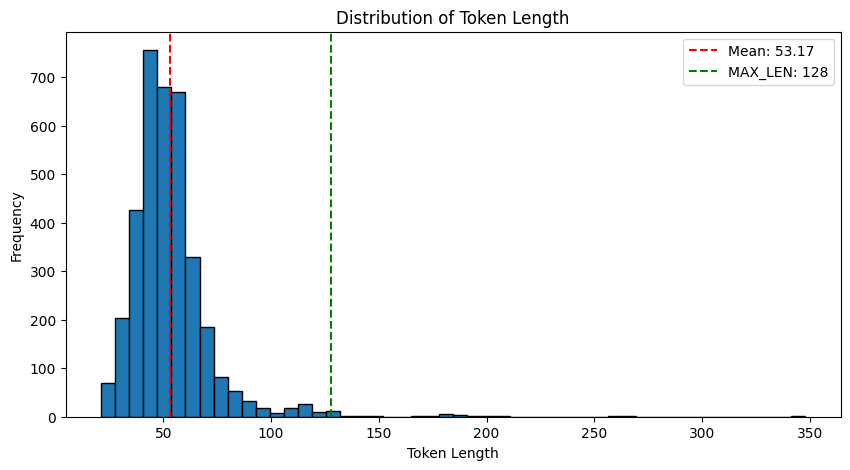


Coverage when MAX_LEN=128: 99.17%


In [9]:
# Token length analysis
token_lengths = []
for text in train_df['text']:
    tokens = tokenizer.encode(text, add_special_tokens=True)
    token_lengths.append(len(tokens))

print("=== Token Length Statistics ===\n")
print(f"Average token count: {np.mean(token_lengths):.2f}")
print(f"Maximum token count: {np.max(token_lengths)}")
print(f"95th percentile: {np.percentile(token_lengths, 95):.0f}")
print(f"99th percentile: {np.percentile(token_lengths, 99):.0f}")

# Visualize token length distribution
plt.figure(figsize=(10, 5))
plt.hist(token_lengths, bins=50, edgecolor='black')
plt.xlabel('Token Length')
plt.ylabel('Frequency')
plt.title('Distribution of Token Length')
plt.axvline(np.mean(token_lengths), color='red', linestyle='--', label=f'Mean: {np.mean(token_lengths):.2f}')
plt.axvline(128, color='green', linestyle='--', label='MAX_LEN: 128')
plt.legend()
plt.show()

# Set maximum length
MAX_LEN = 128  # Most of AG News is under 128
coverage = np.mean(np.array(token_lengths) <= MAX_LEN) * 100
print(f"\nCoverage when MAX_LEN={MAX_LEN}: {coverage:.2f}%")

## 8. Data Preprocessing Function

In [10]:
def preprocess_data(texts, labels, tokenizer, max_len):
    """
    Preprocess text data into BERT input format
    """
    input_ids = []
    attention_masks = []

    for text in texts:
        encoded = tokenizer.encode_plus(
            text,
            add_special_tokens=True,      # Add [CLS], [SEP] tokens
            max_length=max_len,           # Maximum length
            padding='max_length',         # Padding
            truncation=True,              # Truncate if exceeds maximum length
            return_attention_mask=True,   # Return attention mask
            return_tensors='pt'           # Return as PyTorch tensors
        )

        input_ids.append(encoded['input_ids'])
        attention_masks.append(encoded['attention_mask'])

    # Convert lists to tensors
    input_ids = torch.cat(input_ids, dim=0)
    attention_masks = torch.cat(attention_masks, dim=0)
    labels = torch.tensor(labels)

    return input_ids, attention_masks, labels

In [11]:
# Preprocess training data
print("Preprocessing training data...")
train_inputs, train_masks, train_labels = preprocess_data(
    train_df['text'].values,
    train_df['label'].values,
    tokenizer,
    MAX_LEN
)

print(f"Train input_ids shape: {train_inputs.shape}")
print(f"Train attention_masks shape: {train_masks.shape}")
print(f"Train labels shape: {train_labels.shape}")

Preprocessing training data...
Train input_ids shape: torch.Size([3600, 128])
Train attention_masks shape: torch.Size([3600, 128])
Train labels shape: torch.Size([3600])


In [12]:
# Preprocess test data
print("\nPreprocessing test data...")
test_inputs, test_masks, test_labels = preprocess_data(
    test_df['text'].values,
    test_df['label'].values,
    tokenizer,
    MAX_LEN
)

print(f"Test input_ids shape: {test_inputs.shape}")
print(f"Test attention_masks shape: {test_masks.shape}")
print(f"Test labels shape: {test_labels.shape}")


Preprocessing test data...
Test input_ids shape: torch.Size([228, 128])
Test attention_masks shape: torch.Size([228, 128])
Test labels shape: torch.Size([228])


## 9. Create DataLoader

In [13]:
# Set batch size
BATCH_SIZE = 32  # Adjust according to GPU memory

# Split training data into train/validation sets (all together!)
from sklearn.model_selection import train_test_split

# 90% train, 10% validation - split all at once
train_inputs, val_inputs, train_masks, val_masks, train_labels, val_labels = train_test_split(
    train_inputs, train_masks, train_labels,
    test_size=0.1,
    random_state=42,
    stratify=train_labels
)

print(f"\nTraining set size: {len(train_inputs)}")
print(f"Validation set size: {len(val_inputs)}")
print(f"Test set size: {len(test_inputs)}")


Training set size: 3240
Validation set size: 360
Test set size: 228


In [14]:
# Create TensorDataset
train_dataset = TensorDataset(train_inputs, train_masks, train_labels)
val_dataset = TensorDataset(val_inputs, val_masks, val_labels)
test_dataset = TensorDataset(test_inputs, test_masks, test_labels)

# Create DataLoader
train_dataloader = DataLoader(
    train_dataset,
    sampler=RandomSampler(train_dataset),
    batch_size=BATCH_SIZE
)

val_dataloader = DataLoader(
    val_dataset,
    sampler=SequentialSampler(val_dataset),
    batch_size=BATCH_SIZE
)

test_dataloader = DataLoader(
    test_dataset,
    sampler=SequentialSampler(test_dataset),
    batch_size=BATCH_SIZE
)

print(f"\nNumber of training batches: {len(train_dataloader)}")
print(f"Number of validation batches: {len(val_dataloader)}")
print(f"Number of test batches: {len(test_dataloader)}")


Number of training batches: 102
Number of validation batches: 12
Number of test batches: 8


## 10. BERT Model Configuration

In [15]:
# Load BERT model (4-class classification)
NUM_LABELS = 4  # World, Sports, Business, Sci/Tech

print("Loading BERT model...")
model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=NUM_LABELS,
    output_attentions=False,
    output_hidden_states=False
)

# Move model to GPU
model.to(device)

print("\nModel loaded successfully!")
print(f"Total number of parameters: {sum(p.numel() for p in model.parameters()):,}")

Loading BERT model...


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



Model loaded successfully!
Total number of parameters: 109,485,316


## 11. Optimizer and Scheduler Configuration

In [16]:
# Set hyperparameters
EPOCHS = 2
LEARNING_RATE = 2e-5

# Setup optimizer
optimizer = AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    eps=1e-8
)

# Calculate total training steps
total_steps = len(train_dataloader) * EPOCHS

# Set up learning rate scheduler
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=0,
    num_training_steps=total_steps
)

print(f"Total training steps: {total_steps}")
print(f"Batches per epoch: {len(train_dataloader)}")

Total training steps: 204
Batches per epoch: 102


## 12. Define Training Function

In [17]:
def format_time(elapsed):
    """Format time for better readability"""
    elapsed_rounded = int(round(elapsed))
    return str(datetime.timedelta(seconds=elapsed_rounded))


def train_epoch(model, dataloader, optimizer, scheduler, device):
    """Train for one epoch"""
    model.train()
    total_loss = 0

    for step, batch in enumerate(dataloader):
        # Move batch to GPU
        b_input_ids = batch[0].to(device)
        b_input_mask = batch[1].to(device)
        b_labels = batch[2].to(device)

        # Initialize gradient
        model.zero_grad()

        # Forward pass
        outputs = model(
            b_input_ids,
            attention_mask=b_input_mask,
            labels=b_labels
        )

        loss = outputs.loss
        total_loss += loss.item()

        # Backward pass
        loss.backward()

        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        # Update parameters
        optimizer.step()
        scheduler.step()

        # Print progress (every 10 batches)
        if step % 10 == 0 and step != 0:
            print(f'  Batch {step:>5,}  of  {len(dataloader):>5,}.    Loss: {loss.item():.4f}')

    avg_loss = total_loss / len(dataloader)
    return avg_loss


def evaluate(model, dataloader, device):
    """Evaluate model"""
    model.eval()
    total_loss = 0
    predictions, true_labels = [], []

    for batch in dataloader:
        # Move batch to GPU
        b_input_ids = batch[0].to(device)
        b_input_mask = batch[1].to(device)
        b_labels = batch[2].to(device)

        # Don't calculate gradient
        with torch.no_grad():
            outputs = model(
                b_input_ids,
                attention_mask=b_input_mask,
                labels=b_labels
            )

        loss = outputs.loss
        logits = outputs.logits

        total_loss += loss.item()

        # Store predictions
        logits = logits.detach().cpu().numpy()
        label_ids = b_labels.to('cpu').numpy()

        predictions.extend(np.argmax(logits, axis=1))
        true_labels.extend(label_ids)

    avg_loss = total_loss / len(dataloader)
    accuracy = accuracy_score(true_labels, predictions)

    return avg_loss, accuracy, predictions, true_labels

## 13. Model Training

In [18]:
# Save training history
train_losses = []
val_losses = []
val_accuracies = []

print("\n======== Training Started ========\n")

# Measure total training time
total_start_time = time.time()

for epoch in range(EPOCHS):
    print(f'\n======== Epoch {epoch + 1} / {EPOCHS} ========')

    # Training
    print('\nTraining...')
    epoch_start_time = time.time()

    train_loss = train_epoch(model, train_dataloader, optimizer, scheduler, device)

    epoch_time = time.time() - epoch_start_time
    print(f'\n  Average training loss: {train_loss:.4f}')
    print(f'  Training epoch took: {format_time(epoch_time)}')

    # Validation
    print('\nRunning Validation...')
    val_start_time = time.time()

    val_loss, val_accuracy, _, _ = evaluate(model, val_dataloader, device)

    val_time = time.time() - val_start_time
    print(f'  Validation Loss: {val_loss:.4f}')
    print(f'  Validation Accuracy: {val_accuracy:.4f}')
    print(f'  Validation took: {format_time(val_time)}')

    # Save history
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)

total_time = time.time() - total_start_time
print(f"\n======== Training Complete ========")
print(f"Total training time: {format_time(total_time)}")


======== Training Started ========


======== Epoch 1 / 2 ========

Training...
  Batch    10  of    102.    Loss: 1.1861
  Batch    20  of    102.    Loss: 0.8506
  Batch    30  of    102.    Loss: 0.7299
  Batch    40  of    102.    Loss: 0.4724
  Batch    50  of    102.    Loss: 0.5055
  Batch    60  of    102.    Loss: 0.3975
  Batch    70  of    102.    Loss: 0.5167
  Batch    80  of    102.    Loss: 0.3691
  Batch    90  of    102.    Loss: 0.2210
  Batch   100  of    102.    Loss: 0.2844

  Average training loss: 0.6192
  Training epoch took: 0:01:00

Running Validation...
  Validation Loss: 0.2530
  Validation Accuracy: 0.9361
  Validation took: 0:00:02

======== Epoch 2 / 2 ========

Training...
  Batch    10  of    102.    Loss: 0.5003
  Batch    20  of    102.    Loss: 0.2696
  Batch    30  of    102.    Loss: 0.3144
  Batch    40  of    102.    Loss: 0.2281
  Batch    50  of    102.    Loss: 0.1421
  Batch    60  of    102.    Loss: 0.2000
  Batch    70  of    102.    Loss

## 14. Visualize Training Results

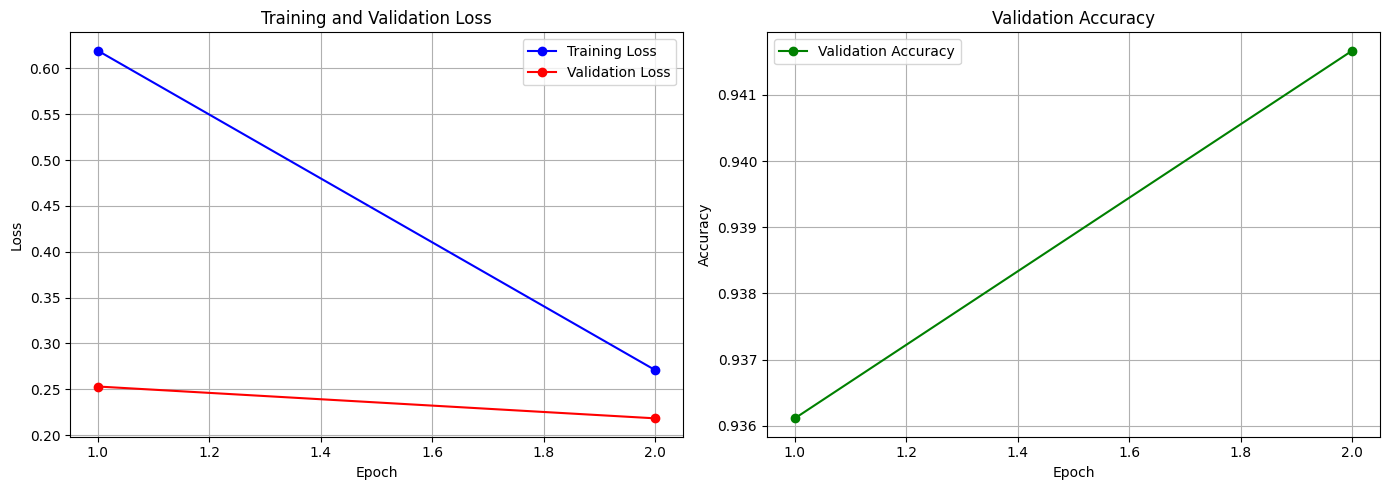


Final validation accuracy: 0.9417


In [19]:
# Visualize training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss graph
axes[0].plot(range(1, EPOCHS + 1), train_losses, 'bo-', label='Training Loss')
axes[0].plot(range(1, EPOCHS + 1), val_losses, 'ro-', label='Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()
axes[0].grid(True)

# Accuracy graph
axes[1].plot(range(1, EPOCHS + 1), val_accuracies, 'go-', label='Validation Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Validation Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

print(f"\nFinal validation accuracy: {val_accuracies[-1]:.4f}")

## 15. Test Data Evaluation

In [20]:
print("\n======== Test Data Evaluation ========\n")

test_start_time = time.time()
test_loss, test_accuracy, test_predictions, test_true_labels = evaluate(
    model, test_dataloader, device
)
test_time = time.time() - test_start_time

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test time: {format_time(test_time)}")


======== Test Data Evaluation ========

Test Loss: 0.3130
Test Accuracy: 0.9035
Test time: 0:00:01


## 16. Detailed Evaluation Metrics

In [21]:
# Classification Report
print("\n=== Classification Report ===\n")
label_names = ['World', 'Sports', 'Business', 'Sci/Tech']
print(classification_report(
    test_true_labels,
    test_predictions,
    target_names=label_names,
    digits=4
))


=== Classification Report ===

              precision    recall  f1-score   support

       World     0.9167    0.8302    0.8713        53
      Sports     0.9403    0.9844    0.9618        64
    Business     0.9184    0.8333    0.8738        54
    Sci/Tech     0.8438    0.9474    0.8926        57

    accuracy                         0.9035       228
   macro avg     0.9048    0.8988    0.8999       228
weighted avg     0.9055    0.9035    0.9026       228



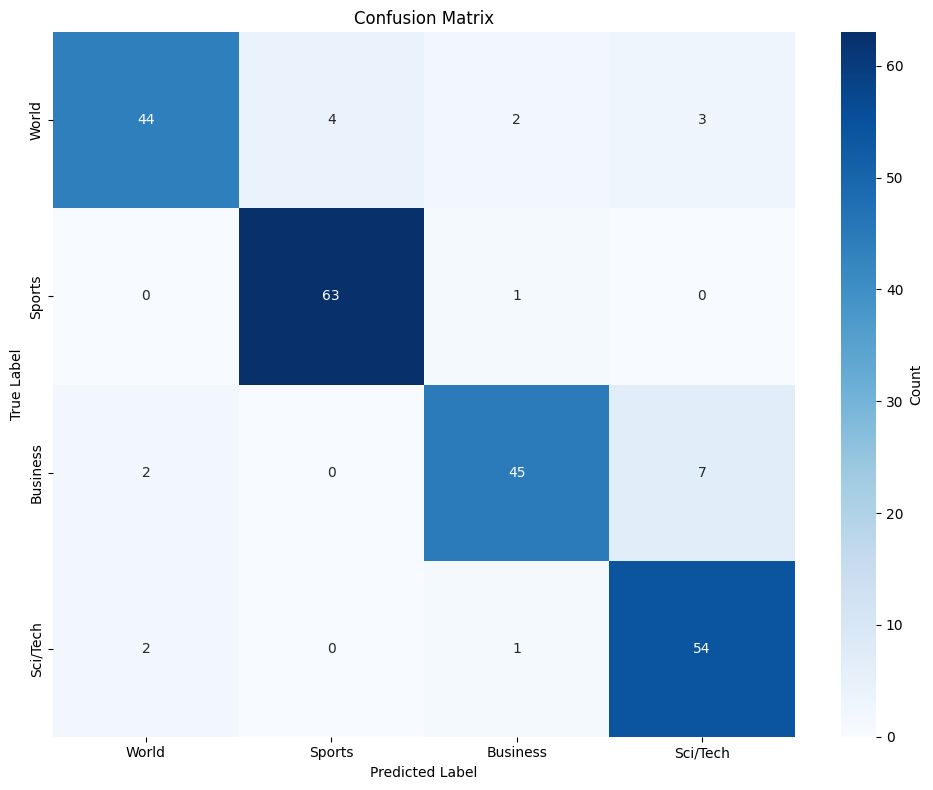


=== Confusion Matrix ===

[[44  4  2  3]
 [ 0 63  1  0]
 [ 2  0 45  7]
 [ 2  0  1 54]]


In [22]:
# Confusion Matrix
cm = confusion_matrix(test_true_labels, test_predictions)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=label_names,
    yticklabels=label_names,
    cbar_kws={'label': 'Count'}
)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

print("\n=== Confusion Matrix ===\n")
print(cm)

## 17. Making Predictions on New Text

In [23]:
def predict_news_category(text, model, tokenizer, device, max_len=128):
    """
    Predict the category of new news text
    """
    # Set model to evaluation mode
    model.eval()

    # Preprocess text
    encoded = tokenizer.encode_plus(
        text,
        add_special_tokens=True,
        max_length=max_len,
        padding='max_length',
        truncation=True,
        return_attention_mask=True,
        return_tensors='pt'
    )

    input_ids = encoded['input_ids'].to(device)
    attention_mask = encoded['attention_mask'].to(device)

    # Prediction
    with torch.no_grad():
        outputs = model(input_ids, attention_mask=attention_mask)
        logits = outputs.logits

    # Calculate probabilities (softmax)
    probs = torch.nn.functional.softmax(logits, dim=1)
    predicted_class = torch.argmax(probs, dim=1).item()
    confidence = probs[0][predicted_class].item()

    return predicted_class, confidence, probs[0].cpu().numpy()

In [24]:
# 예측 테스트
test_texts = [
    "NASA announces new mission to Mars with advanced rover technology",
    "Stock market reaches all-time high amid economic recovery",
    "Football team wins championship in dramatic final match",
    "United Nations holds emergency meeting on climate change"
]

label_names = ['World', 'Sports', 'Business', 'Sci/Tech']

print("\n=== New Text Prediction Results ===\n")

for i, text in enumerate(test_texts, 1):
    predicted_class, confidence, all_probs = predict_news_category(
        text, model, tokenizer, device, MAX_LEN
    )

    print(f"Example {i}:")
    print(f"Text: {text}")
    print(f"Predicted category: {label_names[predicted_class]}")
    print(f"Confidence: {confidence:.4f}")
    print("\nProbability for each category:")
    for label, prob in zip(label_names, all_probs):
        print(f"  {label}: {prob:.4f}")
    print("-" * 80 + "\n")


=== New Text Prediction Results ===

Example 1:
Text: NASA announces new mission to Mars with advanced rover technology
Predicted category: Sci/Tech
Confidence: 0.9003

Probability for each category:
  World: 0.0287
  Sports: 0.0317
  Business: 0.0393
  Sci/Tech: 0.9003
--------------------------------------------------------------------------------

Example 2:
Text: Stock market reaches all-time high amid economic recovery
Predicted category: Business
Confidence: 0.9501

Probability for each category:
  World: 0.0220
  Sports: 0.0100
  Business: 0.9501
  Sci/Tech: 0.0179
--------------------------------------------------------------------------------

Example 3:
Text: Football team wins championship in dramatic final match
Predicted category: Sports
Confidence: 0.9214

Probability for each category:
  World: 0.0445
  Sports: 0.9214
  Business: 0.0130
  Sci/Tech: 0.0211
--------------------------------------------------------------------------------

Example 4:
Text: United Nations ho

## 18. Making Predictions with User Input

In [25]:
# Predict with directly input text
# Change the text below to your desired news content
user_input = "Apple releases new iPhone with revolutionary AI features"

predicted_class, confidence, all_probs = predict_news_category(
    user_input, model, tokenizer, device, MAX_LEN
)

print("\n=== User Input Prediction ===\n")
print(f"Input Text: {user_input}")
print(f"\nPredicted category: {label_names[predicted_class]}")
print(f"Confidence: {confidence:.4f}")
print("\nProbability for each category:")
for label, prob in zip(label_names, all_probs):
    bar = '█' * int(prob * 50)
    print(f"  {label:12s}: {bar} {prob:.4f}")


=== User Input Prediction ===

Input Text: Apple releases new iPhone with revolutionary AI features

Predicted category: Sci/Tech
Confidence: 0.9440

Probability for each category:
  World       :  0.0126
  Sports      :  0.0122
  Business    : █ 0.0311
  Sci/Tech    : ███████████████████████████████████████████████ 0.9440


## 19. Saving Model

In [26]:
# Save model path
output_dir = './ag_news_bert_model/'

# Create directory
import os
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

print(f"Saving model to {output_dir}...")

# Save model
model.save_pretrained(output_dir)
tokenizer.save_pretrained(output_dir)

print("Model saved successfully!")

Saving model to ./ag_news_bert_model/...
Model saved successfully!


## 20. Loading Saved Model

In [27]:
# Example of loading saved model
from transformers import BertForSequenceClassification, BertTokenizer

# Load model and tokenizer
loaded_model = BertForSequenceClassification.from_pretrained(output_dir)
loaded_tokenizer = BertTokenizer.from_pretrained(output_dir)

# Move to GPU
loaded_model.to(device)

print("Loaded saved model successfully!")

# Test prediction with loaded model
test_text = "Scientists discover new species in deep ocean"
predicted_class, confidence, _ = predict_news_category(
    test_text, loaded_model, loaded_tokenizer, device, MAX_LEN
)

print(f"\nTest Text: {test_text}")
print(f"Predicted category: {label_names[predicted_class]}")
print(f"Confidence: {confidence:.4f}")

Loaded saved model successfully!

Test Text: Scientists discover new species in deep ocean
Predicted category: Sci/Tech
Confidence: 0.8754


## 21. Practice Summary and Conclusion

### Practice Overview
1. **Dataset**: AG News English news data (4-class categories)
2. **Model**: BERT (bert-base-uncased)
3. **Task**: Multi-class text classification
4. **Evaluation Metrics**: Accuracy, Precision, Recall, F1-Score

### Key Learning Points
- How to use BERT tokenizer
- Text preprocessing (tokenization, padding, attention mask)
- Utilizing PyTorch DataLoader
- BERT fine-tuning
- Model evaluation and prediction
- Saving and loading models

### Additional Experiment Ideas
1. Try different BERT models (bert-large, roberta, distilbert)
2. Hyperparameter tuning (learning rate, batch size, epochs)
3. Apply data augmentation techniques
4. Build ensemble models
5. Transfer learning with other news datasets